*Do not delete this style setting*

In [1]:
%%html
<style>
table {float:left}
</style>

# Session 3<br> A Simple Quantum Classifier

<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To explore the creation and use of a simple quantum classifier in <strong>PennyLane</strong> and <strong>PyTorch</strong>.<br>
            Compare the quantum classifier with the equivalent classical classifier.<br>
            Note that "simplicity" is only in data and the model structure - not in the approach!</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>October 2026</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>We will use the following two datasets from UCI repository (require: pip install ucimlrepo):<br>
        <ol>
            <li><a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>:
              This is a database of automobile specs. The aim is to determine its insurance risk (symboling). Data loading and preprocessing was included below.
              <font color="red">Note: As the website seems temporarily offline, a slightly different dataset has been made available for local access in "../data/Automobile.csv".</font></li>
            <li><a href="https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks" target="_blank">Sonar</a>:
              The aim is to discriminate between sonar signals bounced off a mine (metal cylinder) or a rock (roughly cylindrical).</li>
        </ol></td></tr>
    <tr><td><strong>Tasks:</strong></td>
        <td>40 minutes (unfinished tasks go to self-directed "challenges")</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks<br>(record your observations at end of this notebook):<br>
        <ol>
            <li>Initially use the <strong><em>Automobiles</em></strong> dataset 1 (as provided).<br>
                Follow the instructor demonstration to step through the code.<br>
                - we will first look at a classical PyTorch model<br>
                - and then look at the quantum PyTorch+PennyLane model.</li>
            <li>Explore your dataset and think of its impact on the process and results:<br>
                - hint: consider data ordering and what needs to be done about it</li>
            <li>Can you improve the model performance by changing the approach<br>to dimensionality reduction:<br>
                - feature selection based on intuition (default) ?<br>
                - feature selection based on f_classif, mutual_info_classif, chi2 ?<br>
                - dimensionality reduction based on PCA ?<br>
                Which of these approaches had the greatest impact on performance?</li>
            <li>Improve the model by varying its architectural and training aspects.<br>
                - changes may apply to data, model and its training<br>
                - what methods have you applied and with what result ?</li>
            <li>Change your PennyLane and Torch model to allow application of<br>
                - <b>sigmoid</b> final activation function, and<br>
                - <b>BCELoss</b> cost function.<br>
                Note 1: You may need to change the quantum measurement to probability.<br>
                Note 2: You may need to add an extra layer mapping qlayer output to BCELoss.</li>
            <li>Create some data on the fantasy automobiles and use the developed model for<br>
                their classification. Does it match your expectation?</li>
            <li>Critically assess the model, its development and training!<br>
                - What principles of quantum model development were broken in the process?</li>
            <li>Compare the classical vs quantum classification models and their performance.</li>
            <li>Reflect on this session.</li>
        </ol></td>
    </tr>
    <tr>
        <td><strong>Challenge<br>Tasks:</strong></td>
        <td>Perform one or more of the following tasks in your own time:<br/>
        <ol style="list-style-type: upper-alpha;">
            <li>Complete the unfinished tasks.</li>
            <li>Change the quantum model by incorporating a full-reuploading ansatz.</li>
            <li>Cleanup and add nominal features to this analysis.</li>
            <li>Add an ROC curve analysis for the best model result (research).</li>
            <li>Include the quantum model definition as part of the <strong><em>Quantum_Auto</em></strong> class.</li>
            <li>Change (back) the label variable from binary to multiclass (hard), <br>
                to implement and test a multinomial classification model (research).</li>
            <li>Create a confusion matrix, with sensitivity and specificity for each class (research).</li>
            <li>Address the critical flaws in the model and its development process.<br>
                - Did you have to retrace the entire experimental process?<br>
                - What is the quantum performance afterwards?<br>
                - What does it mean?</li>
            <li>Apply your completed model to the <strong><em>Sonar</em></strong> data set 2</li>
        </ol></td>
    </tr>
    <tr><td><strong>References:</strong></td>
        <td><ul>
            <li><a href = "https://www.youtube.com/watch?v=OIenNRt2bjg" target="_blank">
                AssemblyAI, “PyTorch Crash Course - Getting Started with Deep Learning”,<br>YouTube Video, Jul 2022.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley, "Turning quantum nodes into Torch Layers",<br>
                PennyLane Demo, October 7, 2024.</a></li>
            <li><a href = "https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">PennyLane, "qml.qnn.TorchLayer",<br>
                PennyLane Documentation, Code API, 2025.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_local_cost_functions" target="_blank">Thomas Storwick, "Alleviating barren plateaus with local cost functions",<br>
                PennyLane Tutorial, November 6, 2024.</a></li>
        </ul></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be recorded in this notebook</td></tr>
</table>

## Libraries

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/pl-qml-2026/lib/python311.zip',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/site-packages',
 '.',
 '..']

In [3]:
### General libraries

import os
import pylab
import math
import time
import copy
import pandas as pd
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("warning")

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
### Import utilities
from utilities import multi_plot_hist, multi_plot_series, draw_circuit

In [5]:
### Import PennyLane and Torch
import pennylane as qml
from pennylane import numpy as np
from pennylane import NesterovMomentumOptimizer
from torch import nn
from torch.autograd import Variable
import torch

---

## <font color="blue">Data preparation</font>
<font color="LightCoral">Task 1: Follow the instructor demonstration to step through the code.</font>
- <font color="LightCoral">we will first look at the classical model</font>
- <font color="LightCoral">and then look at the quantum model.</font>

Selected dataset: <a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>.
  
<font color="CornflowerBlue">_**Data needs to be prepared as follows:**_</font>

- <font color="CornflowerBlue">*Load and understand data*</font>
- <font color="CornflowerBlue">*Select numerical variables only (make it simple)*</font>
- <font color="CornflowerBlue">*Eliminate missing values*</font>
- <font color="CornflowerBlue">*Prepare the label (change it to binary)*</font>
- <font color="CornflowerBlue">*Standardise predictors*</font>
- <font color="CornflowerBlue">*Reduce dimensionality*</font>

<font color="CornflowerBlue">Note that for brevity of this demonstration we will apply data processing to the entire dataset rather than the training and test sets separately.</font>

In [6]:
### Dataset settings
#   Decide how many data features to be modelled (will be transformed)
n_features = 5
data_seed = 2025

### Load and understand data
*The original source of data included for reference.*

In [7]:
# from ucimlrepo import fetch_ucirepo

# auto = fetch_ucirepo(id=10)
# X_vars = auto.data.features 
# y_class = auto.data.targets 
# print(auto.metadata['additional_info']['summary'],'\n') 

In [8]:
import pandas as pd

### Fetch data from the local repository
filepath = '../data/Automobile.csv'
headers = ['symboling','normalized-losses','make','fuel-type','aspiration', 'num-of-doors','body-style',
           'drive-wheels','engine-location','wheel-base', 'length','width','height','curb-weight','engine-type',
           'num-of-cylinders', 'engine-size','fuel-system','bore','stroke','compression-ratio','horsepower',
           'peak-rpm','city-mpg','highway-mpg','price']

automobile = pd.read_csv(filepath, sep='#', decimal='.', header=None, names=headers)
print(f'\nRead "automobile" dataset, with rows={automobile.shape[0]}, columns={automobile.shape[1]}\n')


Read "automobile" dataset, with rows=238, columns=26



In [9]:
automobile.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [10]:
print(automobile.describe(include='all'))

         symboling  normalized-losses    make fuel-type aspiration  \
count   238.000000         191.000000     238       238        238   
unique         NaN                NaN      27         5          5   
top            NaN                NaN  toyota       gas        std   
freq           NaN                NaN      32       207        175   
mean      0.642857         116.863874     NaN       NaN        NaN   
std       1.360446          36.171118     NaN       NaN        NaN   
min      -2.000000          25.000000     NaN       NaN        NaN   
25%       0.000000          94.000000     NaN       NaN        NaN   
50%       0.000000         104.000000     NaN       NaN        NaN   
75%       2.000000         145.000000     NaN       NaN        NaN   
max       4.000000         256.000000     NaN       NaN        NaN   

       num-of-doors body-style drive-wheels engine-location  wheel-base  ...  \
count           236        238          238             238   238.00000  ...   

<br>
<font color="LightCoral">Task 2: Investigate data preparation and its impact on the process and results.</font><br>

- <font color="LightCoral">Hint: consider data ordering and what needs to be done about it</font>

### Preliminary data processing

In [11]:
### Split data frame into X and y vectors
y_class = automobile[['symboling']]
X_vars = automobile.drop(columns=['symboling'])

In [12]:
### After a brief investigation, it is evident that ...
#   this data set has a serious problem and cannot be used as it is!
...

Ellipsis

### Select numerical predictors only

In [13]:
### Select numeric columns only
X_sel = X_vars.select_dtypes(include=np.number)
X_sel.columns

Index(['normalized-losses', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='str')

### Deal with missing values

In [14]:
### Identify columns with missing values
X_sel.isna().sum().loc[lambda x : x > 0].sort_index()

bore                  4
horsepower            2
normalized-losses    47
peak-rpm              2
price                 4
stroke                4
dtype: int64

In [15]:
### Replace missing values with column mean
#   Then check that missing values have been eliminated
auto_xmean = X_sel.mean()
X_sel = X_sel.fillna(auto_xmean)
X_sel.isna().sum().loc[lambda x : x > 0]

Series([], dtype: int64)

### Standardise predictors

In [16]:
# Standardise all variables
from sklearn.preprocessing import StandardScaler, MinMaxScaler
auto_scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled = auto_scaler.fit_transform(X_sel) 
X_std = pd.DataFrame(scaled, columns=X_sel.columns)
# multi_plot_hist(X_std, n_cols = 5, figsize=(8,5.5));

### Prepare the label
<font color="CornflowerBlue">As the label is numeric and multi-class, to simplify the task we turn the label into a binary variable.<br>
The binary class split will be around the distribution mean.</font>

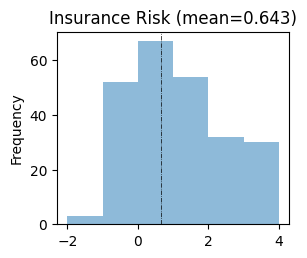

In [17]:
### Observe label distribution
auto_ymean = y_class["symboling"].mean()
ax = y_class.plot.hist(bins=6, alpha=0.5, title=f'Insurance Risk (mean={round(auto_ymean, 3)})', 
                       figsize=(3,2.5))
ax.get_legend().remove()
plt.axvline(auto_ymean, color='k', linestyle='-.', linewidth=0.5);

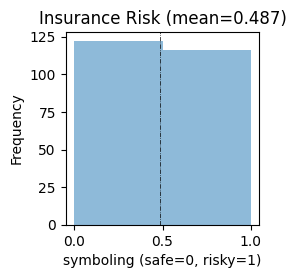

In [18]:
### Create a binary label
pd.set_option('display.max_rows', 10)
y_std = pd.DataFrame(y_class)
y_std['symboling'] = np.where(y_std['symboling'] > auto_ymean, 1, 0)
y_binmean = y_std["symboling"].mean()

ax = y_std.plot.hist(bins=2, alpha=0.5, title=f'Insurance Risk (mean={np.round(y_binmean, 3)})', 
                 figsize=(2.5,2.5))
ax.set_xlabel(f'{y_std.columns[0]} (safe=0, risky=1)')
ax.get_legend().remove()
plt.axvline(y_binmean, color='k', linestyle='-.', linewidth=0.5);

### Reduce data dimensionality

<font color="LightCoral">Task 3: Change the approach to dimensionality reduction.</font><br>
- <font color="LightCoral">Experiment with the following three approaches: based on the hunch, Chi2 feature selection and PCA</font>
- <font color="LightCoral">Which of these approaches had the greatest impact on performance?</font>

<font color="CornflowerBlue">Each method prepares a different version of the dataset: X_hunch, X_kbest, X_pca - assign it to X.</font>

In [19]:
### The number of features to select
col_names = list(X_std.columns)
print(f'\nNumber of features available: {X_std.shape[1]}\n'+\
      f'Number of features to select: {n_features}\n\n'+\
      f'Features: {*col_names,}')


Number of features available: 15
Number of features to select: 5

Features: ('normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price')


#### Feature selection based on intuition

In [20]:
X_hunch = X_std[['engine-size', 'highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower']]
X_hunch.columns

Index(['engine-size', 'highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower'], dtype='str')

#### Feature selection based on statistical analysis (ANOVA F-test or $\chi^2$)

In [21]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif

# Feature extraction
selector = SelectKBest(score_func=f_classif, k=n_features)
X_ext = selector.fit_transform(X_std, y_std)

# Identify selected features
columns_mask = selector.get_support()
sel_features = X_std.columns[columns_mask]
X_kbest = pd.DataFrame(data = X_ext, columns = sel_features)
X_kbest.columns

Index(['wheel-base', 'length', 'width', 'height', 'curb-weight'], dtype='str')

#### Dimensionality reduction with PCA

In [22]:
from sklearn.decomposition import PCA

n_components = n_features
auto_pca = PCA(n_components=n_components)
X_pca = auto_pca.fit_transform(X_std)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{n:02d}' for n in range(X_pca.shape[1])])
pca_var = auto_pca.explained_variance_ratio_
print(f'Explained var = {np.sum(pca_var):02.3f}')
X_pca.columns

Explained var = 0.863


Index(['PC00', 'PC01', 'PC02', 'PC03', 'PC04'], dtype='str')

#### Select an approach to dimensionality reduction
<font color="CornflowerBlue">Select the method of dimensionality reduction by copying the required version of X.<br>
All versions have been defined above.</font>

In [23]:
X = X_hunch.copy()
y = y_std.copy()

***

## <font color="blue">Model development</font>

<font color="LightCoral">Task 4: Improve the model performance.</font><br>
- <font color="LightCoral">Apply changes to data, the model and its training.</font>
- <font color="LightCoral">What methods have you applied and with what result ?</font>

### Utilities

<font color="CornflowerBlue">Note that for the model training purposes, <strong><em>mse_cost</em></strong> defined here cannot be replaced by sklearn <strong><em>mean_squared_error</em></strong>,<br>
as it does not understand gradients. When using PyTorch, we will use its full suite of gradient-aware loss/cost functions.</font><br>
<font color="blue">Beware that PennyLane and PyTorch loss functions take params in different order, params order in PyTorch is very important!</font>

In [24]:
### Performance measures

### A simple MSE cost function
def square_mse(labels, predictions):
    sq_diffs = torch.tensor([(p - l)**2 for l, p in zip(labels, predictions)])
    return sq_diffs.mean().item()

### Calculates accuracy from expval predictions
def accuracy(labels, predictions, prec=1e-5):
    acc = sum(abs(p - l) < prec for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc.item()

### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Define device to compute on
<font color="CornflowerBlue">Note that this workshop notebooks have not been optimised 
for working with GPUs. So, it is best to "force" the CPU based computation or else 
GPU will tremendously slow down your code execution!</font>

In [25]:
### Find what devices are available

# Quantum simulator
sim = 'lightning.qubit' # default.qubit lightning.qubit lightning.gpu

# Enable GPU device if available
if torch.cuda.is_available():   # for Linux / Windows with GPU
    torch_device = 'cuda'
elif torch.mps.is_available():  # for Mac with GPU
    torch_device = 'mps'
else:
    torch_device = 'cpu'        # for everybody else
    
print(f'\nThe available devices:\t{sim} and {torch_device}')

# If you want to force CPU if working with GPU is slow (our unoptimised code)
torch_device = "cpu"

print(f'Devices to be used:\t{sim} and {torch_device}\n')


The available devices:	lightning.qubit and cpu
Devices to be used:	lightning.qubit and cpu



### Model and training configuration

In [26]:
### Data params
n_data = X.shape[0]
x_angle_margin = 0.1
x_angle_min = 0+x_angle_margin
x_angle_max = np.pi-x_angle_margin

### Architectural params
n_wires = X.shape[1]  # The model ansatz may have less data than wires
n_layers = 5
wires = list(range(n_wires))

### Training params
epochs = 50      # 50 # 80 # 100 # 300
log_interv = 1   # History to be saved only once every interv or epochs
acc_prec = 0.5   # Precision of accuracy calculation
shots = None     # None means using theoretical frequency distribution 
seed = 2025

### Prepare data for the quantum classifier

<font color="CornflowerBlue">Note that we have already scaled the X values to the [0..1] range.<br>
That value range was needed to perform PCA, if this dimensionality reduction was to be used.<br>
We could not scale X to the range of values [0..pi] as required for quantum data encoding,<br>
as PCA would have changed that range later on.</font>

In [27]:
### Standardise X values to the range 0+margin..pi-margin
from sklearn.preprocessing import StandardScaler, MinMaxScaler
angle_scaler = MinMaxScaler(feature_range=(x_angle_min, x_angle_max)) 
scaled = angle_scaler.fit_transform(X) 
X = pd.DataFrame(scaled, columns=X.columns)

In [28]:
### Create data partitions, data has been shuffled before
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.iloc[:,0:n_data], y.iloc[:,0:n_data], 
    test_size=0.33, shuffle=False, random_state=seed)
print(f'Shapes: X_train={X_train.shape}, X_test={X_test.shape}, y_train={y_train.shape}, y_test={y_test.shape}')

Shapes: X_train=(159, 5), X_test=(79, 5), y_train=(159, 1), y_test=(79, 1)


In [29]:
### Change the data format to tensors
X_train_tens = torch.tensor(np.array(X_train), dtype=torch.double)
y_train_tens = torch.tensor(np.array(y_train), dtype=torch.double)
X_test_tens  = torch.tensor(np.array(X_test), dtype=torch.double)
y_test_tens  = torch.tensor(np.array(y_test), dtype=torch.double)

### PennyLane model

<font color="CornflowerBlue">Note that this model, unlike the models in Session 1, uses <strong><em>AngleEmbedding</em></strong> function to crate a data encoding block.<br>
However, if you were going to change the model to a full data reuploading ansatz, this function will not be useful.</font>


In [30]:
### Define a simple quantum model
def qmodel(n_wires):
    wires = list(range(n_wires))
    def _qmodel(inputs, weights):
        nonlocal wires, n_wires #, meas_wires
        qml.AngleEmbedding(inputs, wires=wires)        
        qml.StronglyEntanglingLayers(weights, wires=wires)
        return [qml.expval(qml.PauliZ(0))]
    return _qmodel

In [31]:
### Check the model shape
def qshape(n_wires, n_layers=1):
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    return shape

In [32]:
### Test
tdev = qml.device(sim, wires=n_wires, shots=None)
tshape = qshape(n_wires, n_layers)
tweights = torch.rand(tshape, requires_grad=True)
tmodel = qmodel(n_wires)
tcirc = qml.QNode(tmodel, tdev, interface='torch', diff_method='adjoint')
print('\nSample result:', tcirc(X_train_tens[0], tweights),'\n')


Sample result: [tensor(0.1347, grad_fn=<ExecuteTapesBackward>)] 



### PyTorch model with PennyLane layer

<font color="CornflowerBlue">To use PennyLane Torch layers refer to the 
<a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">TorchLayer PennyLane API</a>
as well as <a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley tute on Torch layers</a>.</font>

In [33]:
### Create a PyTorch model with a PennyLane circuit within

class Quantum_Auto(nn.Module):

    def __init__(self, sim, n_wires, n_layers=1, shots=None):
        super(Quantum_Auto, self).__init__()

        self.sim = sim
        self.n_wires = n_wires
        self.n_layers = n_layers
        self.shots = shots

        # Wrap a torch layer around the PennyLane model
        quant_layer = self.qlayer()
        # reduce_layer = torch.nn.Linear(2, 1)
        # layers = [quant_layer, reduce_layer]
        layers = [quant_layer]
        self.model_pt = nn.Sequential(*layers)  

    ### Define a quantum layer
    def qlayer(self):
        
        # Specify a device
        dev = qml.device(self.sim, wires=self.n_wires, shots=self.shots)

        # Define the quantum model and its circuit (or node, save it for later)
        model_pl = qmodel(self.n_wires)
        self.model_qc = qml.QNode(model_pl, dev, interface='torch', diff_method='adjoint')

        # Define the shape of the model weight parameters
        # Note that the name "weights" must match the param name defined in function 
        # "model_pl" which in our case is _qmodel(inputs, weights)
        weights_shapes = {"weights": qshape(self.n_wires, n_layers=self.n_layers)}

        # Turn the circuit into a Torch-compatible quantum layer
        quant_layer = qml.qnn.TorchLayer(self.model_qc, weight_shapes=weights_shapes)
        return quant_layer

    ### Return the quantum model circuit
    def qmodel_qc(self):
        return self.model_qc
 
    ### Apply the model to data (forward step)
    def forward(self, x):
        y = self.model_pt(x)
        # y = sigmoid(self.model_pt(x))
        return y

### Test the PennyLane/PyTorch hybrid model before use

In [34]:
### Create a test model and draw the test model circuit
test = Quantum_Auto(sim, n_wires, n_layers=n_layers, shots=shots).double().to(torch_device)
shape = qshape(n_wires, n_layers)
n_weights = np.prod(shape)

print(f'\nAll weights: {count_params(test)}, Q weights: {n_weights}, Epochs: {epochs}')
print(f'\nTest results: {test(X_train_tens[0:5])}\n')

### Show the structure of the torch model
test.eval()


All weights: 75, Q weights: 75, Epochs: 50

Test results: tensor([[-0.2320],
        [-0.2320],
        [-0.1758],
        [-0.2185],
        [-0.3091]], dtype=torch.float64, grad_fn=<ViewBackward0>)



Quantum_Auto(
  (model_pt): Sequential(
    (0): <Quantum Torch Layer: func=_qmodel>
  )
)

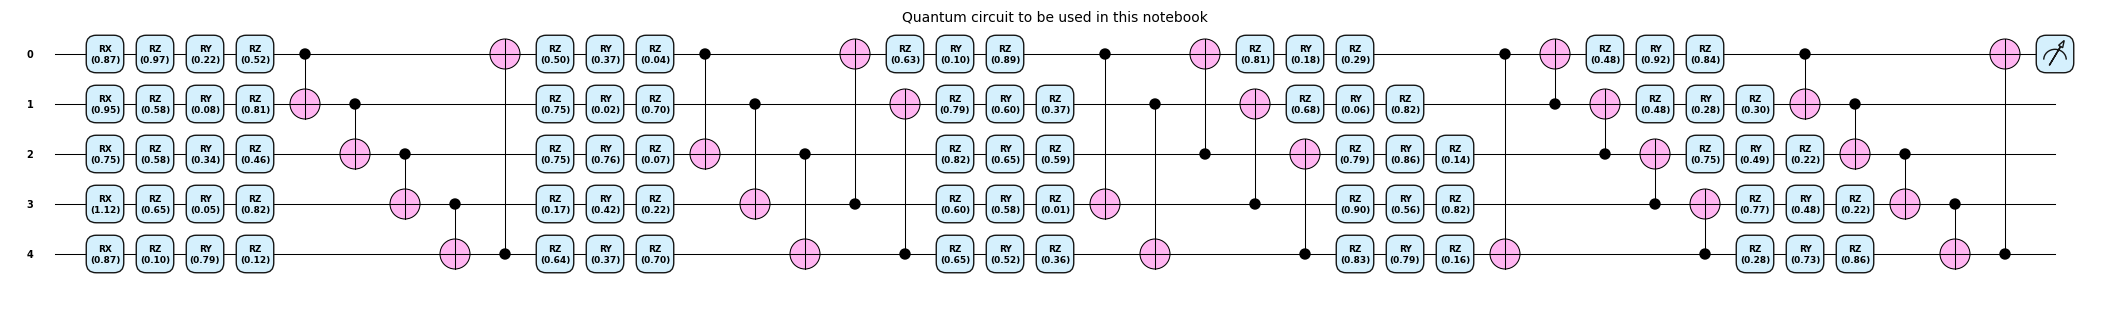

In [35]:
### Draw the test model circuit
weights = torch.rand(shape, requires_grad=True)
draw_circuit(test.qmodel_qc(), scale=0.5, title='Quantum circuit to be used in this notebook', level='device') \
    (X_train_tens[0], weights) # level='device'/'gradient'

### Creation and training of the PennyLane/PyTorch model

In [36]:
### Trains a PyTorch model (of any kind)
def train_model(model, X, y, cost_fun, optimizer, epochs, 
                log_interv=100, prompt_fract=0.1, start_time=0):
    
    history = []
    opt_params = {}
    hist_params = []
    min_epoch = 0
    min_cost = np.inf
    if start_time == 0: start_time = time.time()
    
    model.train()
    for epoch in range(epochs):
        
        optimizer.zero_grad()
        output = model(X)
        cost = cost_fun(output, y)
        cost.backward()
        optimizer.step()

        curr_cost = cost.item()
        if curr_cost < min_cost: 
            min_cost = curr_cost
            min_epoch = epoch
            opt_params = copy.deepcopy(model.state_dict())

        if epoch % log_interv == 0:
            history.append(curr_cost)
            hist_params.append(copy.deepcopy(model.state_dict()))

        elapsed = time.time() - start_time
        if (prompt_fract == 0) or (epoch % int(prompt_fract*epochs) == 0):
            print(f'{epoch: 5d} '+ \
                  f'({elapsed:06.0f} sec): '+ \
                  f'Cost {curr_cost:6.4g}')
            
    return history, opt_params, hist_params, (min_epoch, min_cost)

### Training loop

In [37]:
### Ensure repeatability
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Create a model
q_auto = Quantum_Auto(sim, n_wires, 
                      n_layers=n_layers, shots=shots).double().to(torch_device)

### Loss and optimiser
# cost_fun = nn.CrossEntropyLoss()
cost_fun = nn.MSELoss()

# opt = optim.SGD(model.parameters(),lr=0.01,weight_decay=1e-5)
# opt = torch.optim.Adam(q_auto.parameters())
opt = torch.optim.NAdam(q_auto.parameters(), lr=0.01)

### Train the model
prompt_fract = 0.1
start_time = time.time()
print(f'\nTraining the model:')

train_obj_hist, opt_params, hist_params, opt_point = \
    train_model(q_auto, X_train_tens, y_train_tens, cost_fun, opt, epochs, 
                log_interv=log_interv, prompt_fract=prompt_fract)
elapsed = time.time() - start_time

### Print the training summary
train_min_obj = np.min(train_obj_hist)
train_min_obj_iter = np.argmin(train_obj_hist)

time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nTraining completed: epochs={epochs} '+\
      f'in {elapsed:0.0f} sec ({time_str})\n\t'+
      f'min MSE = {np.round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}')


Training the model:
    0 (000001 sec): Cost 0.5402
    5 (000005 sec): Cost 0.3573
   10 (000009 sec): Cost 0.2763
   15 (000013 sec): Cost  0.244
   20 (000017 sec): Cost   0.23
   25 (000021 sec): Cost 0.2219
   30 (000025 sec): Cost 0.2163
   35 (000029 sec): Cost 0.2125
   40 (000033 sec): Cost 0.2096
   45 (000037 sec): Cost 0.2072

Training completed: epochs=50 in 41 sec (00:00:40)
	min MSE = 0.2056 @ 0049


### Calculate testing scores

In [38]:
### Calculate a model score as defined by the scoring function and data
def score_model(model, params, X, y, score_fun, score_name='Score', score_min=True, prompt_fract=0):

    ### Initialise scoring
    score_hist = []
    if score_min:
        opt_score = float(np.inf)
    else:
        opt_score = -float(np.inf)
    
    ### Calculate scores
    print(f'\nCalculating scores for {score_name}:')
    for iter in range(len(hist_params)):
        model.load_state_dict(params[iter])
        pred = model(X)
        curr_score = score_fun(pred, y)
        if type(curr_score) is torch.Tensor:
            curr_score = curr_score.item()
        score_hist.append(curr_score)
        if (not score_min and (curr_score > opt_score)) or \
           (score_min and (curr_score < opt_score)):
            opt_score = curr_score
            opt_score_iter = iter
        if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
            print(f'{iter:5d} / {epochs:3d}, '+
                  f'{score_name} = {curr_score:.6f}')
    print()
    return score_hist, opt_score, opt_score_iter

In [39]:
### Calculate remaining scores
#   Note: training costs (MSE) have already been calculated

train_acc_hist, train_max_acc, train_max_acc_iter = \
    score_model(q_auto, hist_params, X_train_tens, y_train_tens, 
    lambda pred, targ: accuracy(pred, targ, prec=acc_prec), 
    score_name='Train Acc', score_min=False, prompt_fract=prompt_fract)
test_obj_hist, test_min_obj, test_min_obj_iter = \
    score_model(q_auto, hist_params, X_test_tens, y_test_tens, cost_fun, 
    score_name='Test MSE', score_min=True, prompt_fract=prompt_fract)
test_acc_hist, test_max_acc, test_max_acc_iter = \
    score_model(q_auto, hist_params, X_test_tens, y_test_tens, 
    lambda pred, targ: accuracy(pred, targ, prec=acc_prec), 
    score_name='Test Acc', score_min=False, prompt_fract=prompt_fract)


Calculating scores for Train Acc:
    0 /  50, Train Acc = 0.421384
    5 /  50, Train Acc = 0.421384
   10 /  50, Train Acc = 0.440252
   15 /  50, Train Acc = 0.647799
   20 /  50, Train Acc = 0.660377
   25 /  50, Train Acc = 0.691824
   30 /  50, Train Acc = 0.704403
   35 /  50, Train Acc = 0.735849
   40 /  50, Train Acc = 0.742138
   45 /  50, Train Acc = 0.723270


Calculating scores for Test MSE:
    0 /  50, Test MSE = 0.257459
    5 /  50, Test MSE = 0.210705
   10 /  50, Test MSE = 0.223406
   15 /  50, Test MSE = 0.248062
   20 /  50, Test MSE = 0.264569
   25 /  50, Test MSE = 0.272209
   30 /  50, Test MSE = 0.274946
   35 /  50, Test MSE = 0.276224
   40 /  50, Test MSE = 0.277532
   45 /  50, Test MSE = 0.278961


Calculating scores for Test Acc:
    0 /  50, Test Acc = 0.696203
    5 /  50, Test Acc = 0.696203
   10 /  50, Test Acc = 0.696203
   15 /  50, Test Acc = 0.544304
   20 /  50, Test Acc = 0.417722
   25 /  50, Test Acc = 0.468354
   30 /  50, Test Acc = 0.4

In [40]:
### Run summary
time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nCompleted calculation of testing scores\n\nSummary of model training run\n\n\t'+
      f'params = {count_params(q_auto)}, '+
      f'epochs = {epochs}, '+
      f'time = {elapsed:0.0f}sec ({time_str})\n\t'+
      f'training: MSE = {np.round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}, '+
      f'ACC = {np.round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}\n\t'+
      f'testing:  MSE = {np.round(test_min_obj, 5):05.4f} @ {test_min_obj_iter:04d}, '+
      f'ACC = {np.round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}'+
      f'\n'
     )


Completed calculation of testing scores

Summary of model training run

	params = 75, epochs = 50, time = 41sec (00:00:40)
	training: MSE = 0.2056 @ 0049, ACC = 0.7421 @ 0037
	testing:  MSE = 0.2102 @ 0006, ACC = 0.7595 @ 0011



### Plot costs and scores

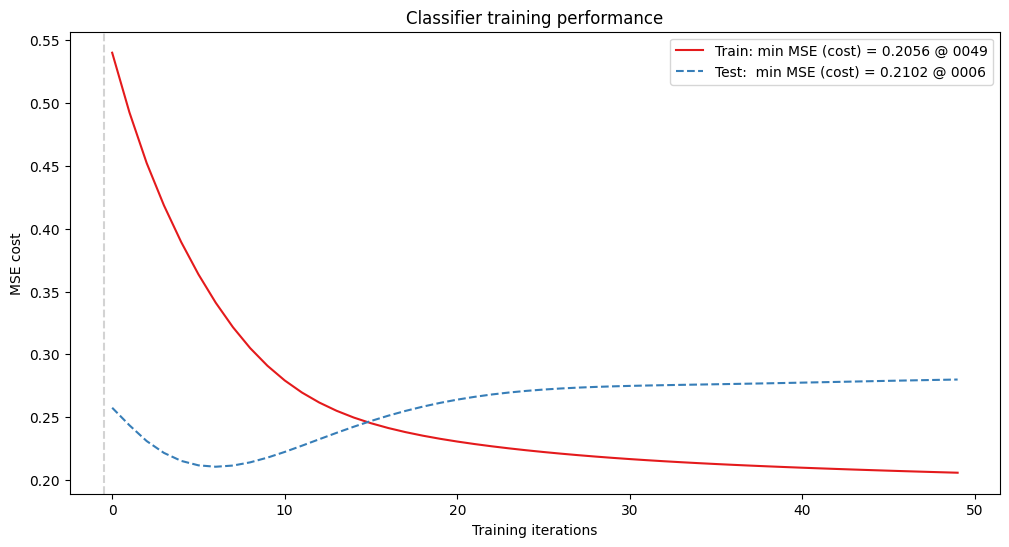

In [41]:
train_label = f'Train: min MSE (cost) = {round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}'
test_label =  f'Test:  min MSE (cost) = {round(test_min_obj, 5):05.4f} @ {test_min_obj_iter:04d}'
multi_plot_series(
    [train_obj_hist, test_obj_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='MSE cost',
    legend_cols=1, smooth_weight=0.2, title='Classifier training performance')

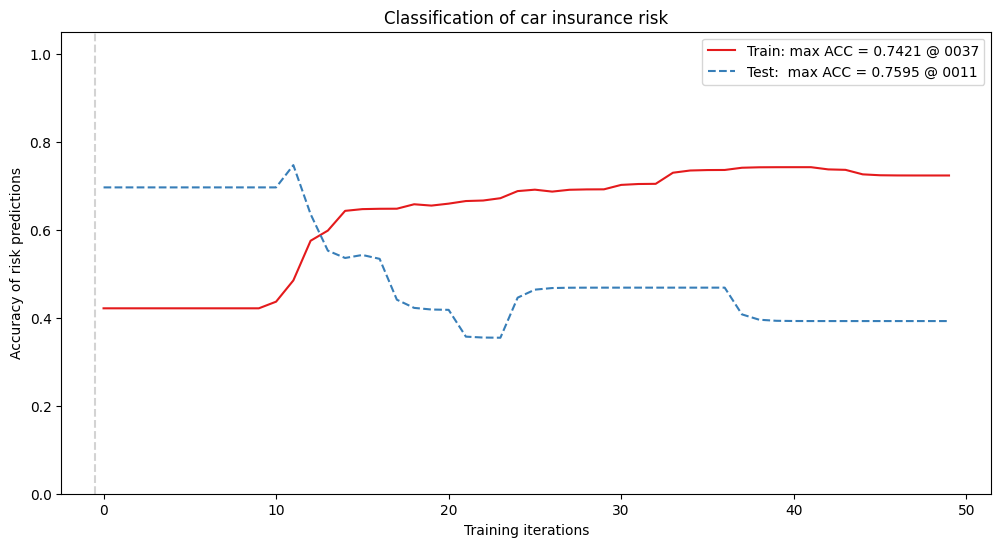

In [42]:
train_label = f'Train: max ACC = {round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}'
test_label =  f'Test:  max ACC = {round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}'
multi_plot_series(
    [train_acc_hist, test_acc_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], ylim=(0, 1.05), # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='Accuracy of risk predictions',
    legend_cols=1, smooth_weight=0.2, title='Classification of car insurance risk')

---

## Write your observations here

- Task 1:
- Task 2:
- Task 3:
- Task 4:
- Task 5:
- Task 6:
- Task 7:
- Task 8:
- Challenge:
- Reflection:

## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 9 April): Now also compatible with...<br>
  pennylane                 0.44.1<br>
  pennylane_lightning       0.44.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>

## Software (Linux)

In [43]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.45.0
pennylane_catalyst        0.15.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
